<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 141 &#183; Extended Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Multi-File, Multi-Date EDA</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">The unglamorous 80% of real data science: three messy exports, mismatched keys, four date formats, currency stored as text, duplicates and orphans. We turn them into one clean, analysis-ready table, and only then explore it.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 1 &#183; FRAME</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Before any analysis, one clean table</div>
<div style="color:#4a5578;margin-top:6px">Real data arrives in pieces, and dirty.</div>
</div>

Every analysis in this book assumed a tidy dataframe. This chapter is about how you *get* one. A typical business question, how is revenue trending and who returns the most, has its data spread across separate exports: an **orders** file, a **customers** file, and a **returns** file, each with its own quirks. Before a single chart, we must **join** them on a shared key and **clean** the mismatches. Getting this wrong silently corrupts every number downstream, so it deserves the same rigor as the modeling.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 2 &#183; LOAD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Read the three files and face the mess</div>
<div style="color:#4a5578;margin-top:6px">Look before you clean.</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
EM='#e11d48'; DEEP='#be123c'; LIGHT='#fecdd3'; INK='#1a2138'; GRID='#e6e9f2'; GREEN='#059669'; AMBER='#d97706'; GREY='#94a3b8'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','figure.dpi':110,'font.size':11,
   'axes.edgecolor':GRID,'axes.grid':True,'grid.color':GRID,'axes.axisbelow':True,'axes.spines.top':False,
   'axes.spines.right':False,'axes.titlesize':12,'axes.titleweight':'bold','legend.frameon':False})
BASE='https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/'
def load(name):
    try:    return pd.read_csv('../../data/'+name)
    except FileNotFoundError: return pd.read_csv(BASE+name)
orders_raw = load('ch141_orders.csv'); customers_raw = load('ch141_customers.csv'); returns_raw = load('ch141_returns.csv')
print('raw rows -> orders:', len(orders_raw), '| customers:', len(customers_raw), '| returns:', len(returns_raw))
orders_raw.head(5)

raw rows -> orders: 1240 | customers: 315 | returns: 150


,order_id,customer_id,order_date,amount,status
0,O00344,C9007,01/01/2024,"1,052.75",SHIPPED
1,O00793,C0146,02-Jul-2024,$356.51,Delivered
2,O00568,C0119,06-Feb-2023,$271.30,delivered
3,O00575,C0249,2024-09-02,446.49,Delivered
4,O00166,C0163,2024-02-20,282.04,shipped


Straight away the problems are visible in `orders`: the **order_date** column mixes `2024-03-15`, `03/15/2024`, and `15-Mar-2024`; **amount** is text like `"$1,299.00"`; **status** appears as `shipped`, `Shipped`, and `SHIPPED`; and pandas has read every column as a generic `object` because of the inconsistency. The other two files have their own issues. We will fix them one class of problem at a time.

In [2]:
print('orders dtypes:'); print(orders_raw.dtypes)
print('\nsample messy values:')
print(' order_date:', orders_raw.order_date.head(4).tolist())
print(' amount    :', orders_raw.amount.head(4).tolist())
print(' status    :', sorted(orders_raw.status.unique())[:8])
print(' customers.region:', sorted(customers_raw.region.dropna().unique().tolist())[:10])

orders dtypes:
order_id       str
customer_id    str
order_date     str
amount         str
status         str
dtype: object

sample messy values:
 order_date: ['01/01/2024', '02-Jul-2024', '06-Feb-2023', '2024-09-02']
 amount    : ['1,052.75', '$356.51', '$271.30', '446.49']
 status    : ['CANCELLED', 'Canceled', 'Cancelled', 'DELIVERED', 'Delivered', 'SHIPPED', 'Shipped', 'cancelled']
 customers.region: ['CA', 'Canada', 'U.K.', 'U.S.', 'UK', 'USA', 'United Kingdom', 'United States', 'canada', 'us']


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 3 &#183; MISSING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Normalize every flavor of 'missing'</div>
<div style="color:#4a5578;margin-top:6px">One NaN, not five spellings of it.</div>
</div>

Real exports encode missing values a dozen ways: an empty cell, `N/A`, `null`, a lone dash. If we do not unify them, `"N/A"` counts as a real category and breaks every summary. We reload declaring **all** of them as missing, so pandas gives us a single, honest `NaN`.

In [3]:
NA = ['', 'N/A', 'null', '-']              # every spelling of 'missing' in these exports
def loadna(name):
    try:    return pd.read_csv('../../data/'+name, na_values=NA, keep_default_na=True)
    except FileNotFoundError: return pd.read_csv(BASE+name, na_values=NA, keep_default_na=True)
orders = loadna('ch141_orders.csv'); customers = loadna('ch141_customers.csv'); returns = loadna('ch141_returns.csv')
print('missing per orders column after normalizing sentinels:'); print(orders.isna().sum())

missing per orders column after normalizing sentinels:
order_id        0
customer_id     0
order_date      0
amount         38
status          0
dtype: int64


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 4 &#183; KEYS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Clean the join key on both sides</div>
<div style="color:#4a5578;margin-top:6px">A join only works if the keys match exactly.</div>
</div>

The files link on `customer_id`, but the ids are inconsistently formatted: some are lowercase (`c0007`), some carry a trailing space (`"C0012 "`). A join matches on **exact** strings, so `"c0007"` and `"C0007"` would fail to link and silently create orphans. We normalize the key, strip whitespace and uppercase, on **both** tables before joining.

In [4]:
for d in (orders, customers):
    d['customer_id'] = d['customer_id'].str.strip().str.upper()
print('distinct customer_id in orders   :', orders.customer_id.nunique())
print('distinct customer_id in customers:', customers.customer_id.nunique())
print('example ids now uniform:', orders.customer_id.head(3).tolist())

distinct customer_id in orders   : 301
distinct customer_id in customers: 300
example ids now uniform: ['C9007', 'C0146', 'C0119']


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 5 &#183; DEDUP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Drop the duplicate rows</div>
<div style="color:#4a5578;margin-top:6px">Exports double up; sums must not.</div>
</div>

In [5]:
before = len(orders), len(customers)
orders = orders.drop_duplicates().copy(); customers = customers.drop_duplicates().copy()   # .copy() -> avoid SettingWithCopyWarning downstream
print(f'orders   : {before[0]} -> {len(orders)} rows  ({before[0]-len(orders)} duplicates removed)')
print(f'customers: {before[1]} -> {len(customers)} rows  ({before[1]-len(customers)} duplicates removed)')

orders   : 1240 -> 1200 rows  (40 duplicates removed)
customers: 315 -> 300 rows  (15 duplicates removed)


Forty duplicate order rows and fifteen duplicate customer rows are gone. This matters enormously: had we summed revenue first, those duplicates would have **inflated the total**. Deduplicate before you aggregate, and do it after cleaning the key (so near-duplicates that differed only by `"C0012"` vs `"C0012 "` collapse too).

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 6 &#183; DATES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Parse three different date formats</div>
<div style="color:#4a5578;margin-top:6px">A date stored as text is not a date.</div>
</div>

Each file dates things its own way: orders mix several formats, signups use `05-Jan-2023`, returns use `2023/07/22`. We parse each with the right rule. For the mixed order dates, pandas' `format='mixed'` infers per value; we set `dayfirst=False` deliberately, because guessing wrong on `03/04/2024` silently swaps March and April (the subject of a Take It Further extension).

In [6]:
orders['order_date']   = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=False)
customers['signup_date']= pd.to_datetime(customers['signup_date'], format='%d-%b-%Y')
returns['return_date'] = pd.to_datetime(returns['return_date'], format='%Y/%m/%d')
print('order_date dtype:', orders.order_date.dtype, '| failed parses (NaT):', int(orders.order_date.isna().sum()))
print('date range:', orders.order_date.min().date(), 'to', orders.order_date.max().date())

order_date dtype: datetime64[us] | failed parses (NaT): 0
date range: 2023-01-01 to 2024-12-30


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 7 &#183; NUMBERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn currency text into numbers</div>
<div style="color:#4a5578;margin-top:6px">You cannot sum a string.</div>
</div>

In [7]:
orders['amount'] = pd.to_numeric(orders['amount'].str.replace(r'[$,]', '', regex=True), errors='coerce')
print('amount dtype now:', orders.amount.dtype)
print('orders with a missing amount (cannot be summed):', int(orders.amount.isna().sum()))
print('mean order amount: %.2f' % orders.amount.mean())

amount dtype now: float64
orders with a missing amount (cannot be summed): 37
mean order amount: 370.29


Stripping the dollar signs and thousands-commas, then coercing to a number, turns `"$1,299.00"` into `1299.0`. Using `errors='coerce'` means any value that still cannot be parsed becomes `NaN` rather than crashing the whole column, and we count them: **37 orders** arrived with no amount at all. We cannot invent those figures, so we will carry them as missing and flag them, this is why our realized-revenue total is honestly a slight *under*-count.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 8 &#183; CATEGORIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Standardize the text categories</div>
<div style="color:#4a5578;margin-top:6px">'USA' and 'U.S.' are the same country.</div>
</div>

In [8]:
region_map = {'USA':'United States','U.S.':'United States','US':'United States',
              'CA':'Canada','UK':'United Kingdom','U.K.':'United Kingdom'}
customers['region'] = (customers['region'].str.strip().replace(region_map)
                       .str.title().replace({'Uk':'United Kingdom','Ca':'Canada','Us':'United States'}))
orders['status'] = orders['status'].str.strip().str.lower().replace({'canceled':'cancelled'})
print('regions ->', sorted(customers.region.dropna().unique()))
print('statuses ->', sorted(orders.status.unique()))

regions -> ['Canada', 'United Kingdom', 'United States']
statuses -> ['cancelled', 'delivered', 'shipped']


The seven spellings of three countries collapse to a clean set, and the case-jumbled statuses (with both British `cancelled` and American `canceled`) become three tidy categories. Without this, a `groupby('region')` would scatter one country across four rows, and any status filter would silently miss half its matches.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 9 &#183; MERGE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Join the three tables, and catch the orphans</div>
<div style="color:#4a5578;margin-top:6px">The moment of truth for the keys.</div>
</div>

In [9]:
m = orders.merge(customers, on='customer_id', how='left', indicator=True)
m['is_orphan'] = m['_merge']=='left_only'                  # order whose customer_id matches nobody
print(f'orders with no matching customer (orphans): {int(m.is_orphan.sum())}')
print(m['_merge'].value_counts().to_string())
m = m.drop(columns='_merge').merge(returns[['order_id','return_date']], on='order_id', how='left')
m['is_returned'] = m['return_date'].notna()
print('\nclean merged table:', m.shape, '| returned orders:', int(m.is_returned.sum()))

orders with no matching customer (orphans): 8
_merge
both          1192
left_only        8
right_only       0

clean merged table: (1200, 10) | returned orders: 150


A **left join** keeps every order and attaches its customer's region; the `indicator=True` flag then reveals **8 orphan orders** whose `customer_id` matches no customer, a data-quality issue worth reporting back to the source, not hiding. Joining the returns with another left join and flagging `is_returned` gives us the single analysis-ready table we set out to build.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 10 &#183; VALIDATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sanity-check before you trust it</div>
<div style="color:#4a5578;margin-top:6px">Cleaning that is not verified is just hoping.</div>
</div>

In [10]:
assert m.order_id.is_unique, 'duplicate order ids remain!'
checks = {
  'rows': len(m),
  'date range ok': bool(m.order_date.min().year==2023 and m.order_date.max().year<=2024),
  'amounts non-negative': bool((m.amount.dropna()>=0).all()),
  'regions': m.region.nunique(dropna=True),
  'orders missing amount': int(m.amount.isna().sum()),
  'orphan orders (no customer match)': int(m.is_orphan.sum()),
  'orders with no region on file': int(m.region.isna().sum()),
}
for k,v in checks.items(): print(f'  {k:34s}: {v}')
print('\nall structural checks passed.')

  rows                              : 1200
  date range ok                     : True
  amounts non-negative              : True
  regions                           : 3
  orders missing amount             : 37
  orphan orders (no customer match) : 8
  orders with no region on file     : 84

all structural checks passed.


A handful of cheap assertions catch the errors that silently poison an analysis: no duplicate order ids survived, dates fall in the expected window, amounts are non-negative, and exactly three regions remain. We also surface what is still imperfect: **37 missing amounts**, **8 orphan orders** whose customer matches nobody, and a larger count of orders with **no region on file** (the 8 orphans plus customers who simply left region blank), so nothing is swept under the rug. This is the checklist that separates *cleaned* from *assumed clean*.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 11 &#183; EDA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Now, finally, explore the clean data</div>
<div style="color:#4a5578;margin-top:6px">The payoff: charts you can trust.</div>
</div>

realized revenue: $388,045 (excludes 30 orders with missing amount)
overall return rate: 13.8%


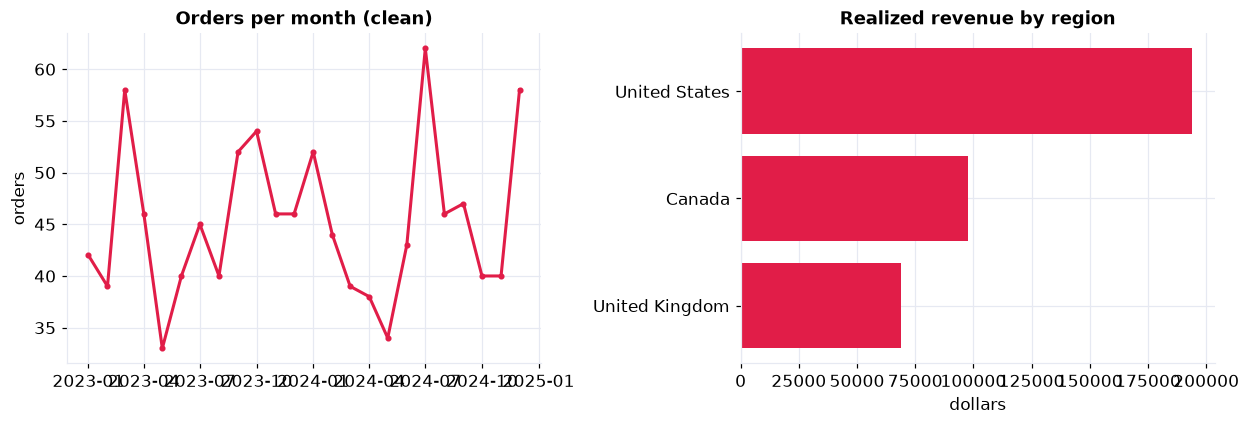


revenue by region:
region
United States     194037.0
Canada             97623.0
United Kingdom     68818.0


In [11]:
realized = m[m.status!='cancelled'].copy()      # revenue is realized on non-cancelled orders
rev = realized.amount.sum(); rate = realized.is_returned.mean()
print(f'realized revenue: ${rev:,.0f} (excludes {int(realized.amount.isna().sum())} orders with missing amount)')
print(f'overall return rate: {rate*100:.1f}%')
fig, ax = plt.subplots(1, 2, figsize=(11.5,4))
monthly = realized.set_index('order_date').resample('MS').agg(orders=('order_id','size'), revenue=('amount','sum'))
ax[0].plot(monthly.index, monthly.orders, color=EM, lw=2, marker='o', ms=3)
ax[0].set(title='Orders per month (clean)', ylabel='orders')
reg = realized.groupby('region').amount.sum().sort_values()
ax[1].barh(reg.index, reg.values, color=EM)
ax[1].set(title='Realized revenue by region', xlabel='dollars')
plt.tight_layout(); plt.show()
print('\nrevenue by region:'); print(reg.sort_values(ascending=False).round(0).to_string())

Only now, on a table we trust, do the business answers appear: about **388,000 dollars** of realized revenue, a **13.8% return rate**, a steady monthly order flow, and the United States as the largest market (roughly 194,000 dollars, about half the total). Every one of these numbers would have been wrong, inflated by duplicates, scattered by region spellings, or crashed by text amounts, had we skipped the cleaning.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The memo, and a reusable checklist</div>
<div style="color:#4a5578;margin-top:6px">Cleaning is a process you can repeat.</div>
</div>

**For the analytics team:** After consolidating the three exports into one clean table (1,200 unique orders across 300 customers), realized revenue was about **388,000 dollars** at a **13.8% return rate**, led by the United States. Two data-quality issues to fix at the source: **37 orders** exported with no amount (so revenue is a slight under-count), and **8 orders** reference customers missing from the customer file. The repeatable checklist we used: **(1)** normalize missing-value sentinels, **(2)** clean and standardize join keys on every table, **(3)** drop duplicate rows, **(4)** parse each date column with its own format, **(5)** convert currency and numeric text to numbers, **(6)** standardize text categories, **(7)** join with an indicator to catch orphans, and **(8)** assert structural checks before trusting any total.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>